1.LOAD DATASET

In [13]:
import pandas as pd

PLATFORM = "Twitter"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/twitter_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/twitter_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(35740, 56)
(8936, 56)


In [14]:
# --- CODE FOR VIEWING POPULARITY VALUES HERE ---
print("\n" + "="*30)
print("Class distribution in the training set")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nRatio %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("Class distribution in the test set")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nRatio %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


Class distribution in the training set
popularity
0    28550
1     7190
Name: count, dtype: int64

Ratio %:
popularity
0    79.882485
1    20.117515
Name: proportion, dtype: float64

Class distribution in the test set
popularity
0    7138
1    1798
Name: count, dtype: int64

Ratio %:
popularity
0    79.879141
1    20.120859
Name: proportion, dtype: float64


In [18]:
# 1. Calculate the Ratio for scale_pos_weight
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Anti-lazy activated! scale_pos_weight = {ratio:.2f}")

Anti-lazy activated! scale_pos_weight = 3.97


In [19]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [20]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# 2. Create XGBoost model with Combo: Anti-lazy (Ratio) + Anti-overfitting (Colsample)
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [21]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [22]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [24]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.80      0.86      7138
           1       0.50      0.82      0.62      1798

    accuracy                           0.80      8936
   macro avg       0.72      0.81      0.74      8936
weighted avg       0.86      0.80      0.82      8936

ROC-AUC  : 0.8930


In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[5687 1451]
 [ 330 1468]]


In [26]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.322360
5              verified    0.126324
40      language_Korean    0.014595
28         topic_Health    0.014149
36      language_French    0.012957
10       toxicity_score    0.012463
18  sentiment_intensity    0.012371
6        content_length    0.012264
8    sentiment_positive    0.012233
9    sentiment_negative    0.012205
25        topic_Finance    0.012043
4      account_age_days    0.012025
44      media_type_Poll    0.011955
39    language_Japanese    0.011879
29       topic_Politics    0.011744


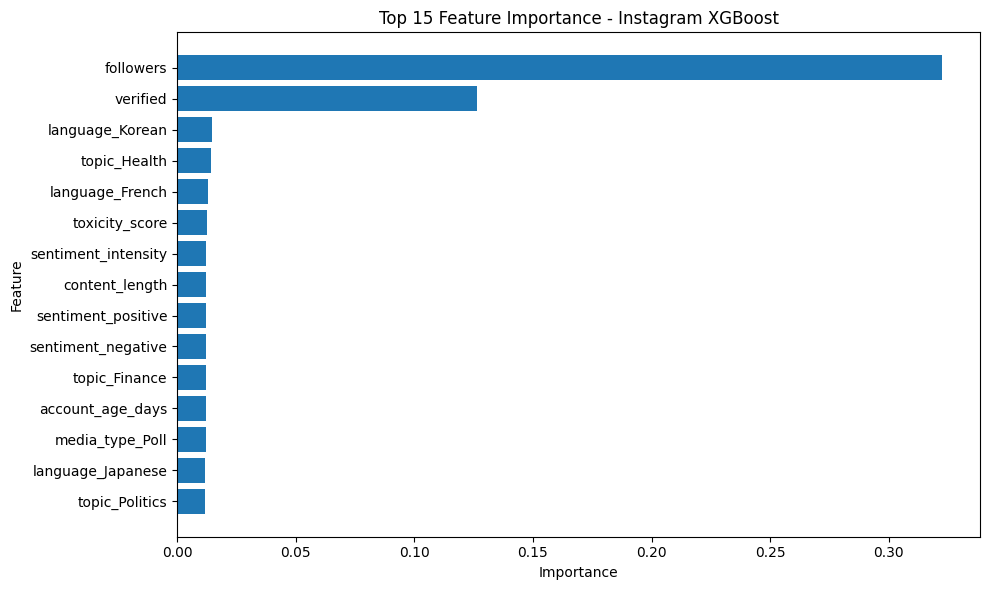

In [27]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Instagram XGBoost"
)

plt.tight_layout()

plt.show()